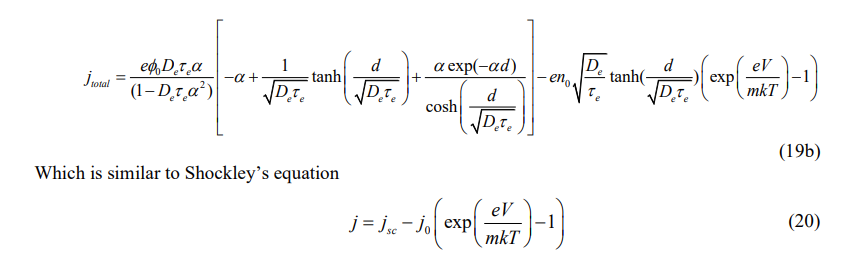


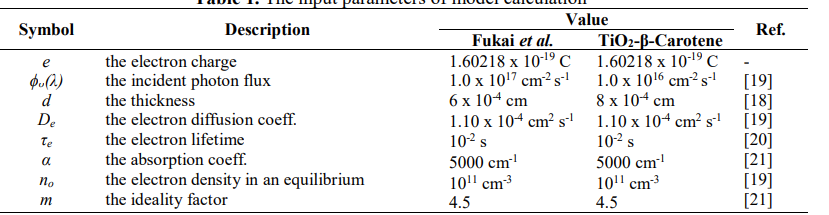



In [ ]:
import numpy as np 
import pandas as pd
from scipy import constants , optimize
import matplotlib.pyplot as plt 
import scienceplots
plt.style.use(['science','no-latex','ieee'])
#import warnings

e, kB = constants.e, constants.Boltzmann
phi_0, d, T, alpha =1e16 ,8e-4 ,3e2, 5e3

def extended_shockley(V, m, n_0, tau_e, D_e):#, phi_0=phi0, d=d0, T=T0, alpha=alpha0):
    """ extended shockley equation is an shockley like's equation derive from maxwell equation?

    Args:
        V (float): voltage
        m (_float_): ideality factor constrains to 1 - 10
        n_0 (_float_): electron density in equilibrium
        tau_e (_float_): electron lifetime
        phi_0 (_float_, estimated): incident photon flux. Defaults to phi0.
        d (_float_, estimated): thickness. Defaults to d0.
        T (_float_, estimated): temperature. Defaults to T0.
        alpha (_type_, estimated): absorption coefficient. Defaults to alpha0.

    Returns:
        float: total current density
    """
    # Diffusion length L
    L = np.sqrt(D_e * tau_e)
    
    # Pre-factor for the first large bracket
    denom = 1 - (L**2 * alpha**2)
    term1_prefix = (e * phi_0 * L**2 * alpha) / denom
    
    # Contents of the square bracket []
    bracket = -alpha + (1/L * np.tanh(d/L)) + (alpha * np.exp(-alpha * d) / np.cosh(d/L))
    
    # short circuit current (density) , can be estimate from I with V ~ 0
    j_sc = term1_prefix * bracket
    
    # sqrt(D_e/tau_e) is the diffusion velocity
    j_0 = e * n_0 * np.sqrt(D_e / tau_e) * np.tanh(d/L)
    
    # Equation 20: j = j_sc - j_0 * (exp(eV/mkT) - 1)
    j_total = j_sc - j_0 * (np.exp((e * V) / (m * kB * T)) - 1)
    
    return j_total

file = "./data/shakinah.xlsx"
data = [pd.read_excel(file,sheet,header=2)  for sheet in pd.ExcelFile(file).sheet_names]
jsc_from_data = data[0].iloc[data[0]["WE(1).Potential (V)"].abs().idxmin(), 2]
I,V =data[0]["mili A"], data[0]["WE(1).Potential (V)"]

initial_geuss = [ 4.5, 1e11, 1e-2, 1e-4] # from reference
low_lim, up_lim = [1, 0, 0, 0],[10, np.inf, np.inf, np.inf]
prams, covs = optimize.curve_fit(extended_shockley,V,I)#,p0=initial_geuss), bounds=(low_lim, up_lim),full_output=True)

/tmp/ipykernel_148668/3030564504.py:29: RuntimeWarning: invalid value encountered in sqrt
  L = np.sqrt(D_e * tau_e)
/tmp/ipykernel_148668/3030564504.py:42: RuntimeWarning: invalid value encountered in sqrt
  j_0 = e * n_0 * np.sqrt(D_e / tau_e) * np.tanh(d/L)
/tmp/ipykernel_148668/3030564504.py:56: OptimizeWarning: Covariance of the parameters could not be estimated
  prams, covs = optimize.curve_fit(extended_shockley,V,I)#,p0=initial_geuss), bounds=(low_lim, up_lim),full_output=True)


In [35]:
def  shockley(V, j0, m):
    return jsc_from_data -j0 *(np.exp(e*V/(m*kB*T)-1))
prams, covs = optimize.curve_fit(shockley,V,I,bounds=([1,0],[10,np.inf]))

findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


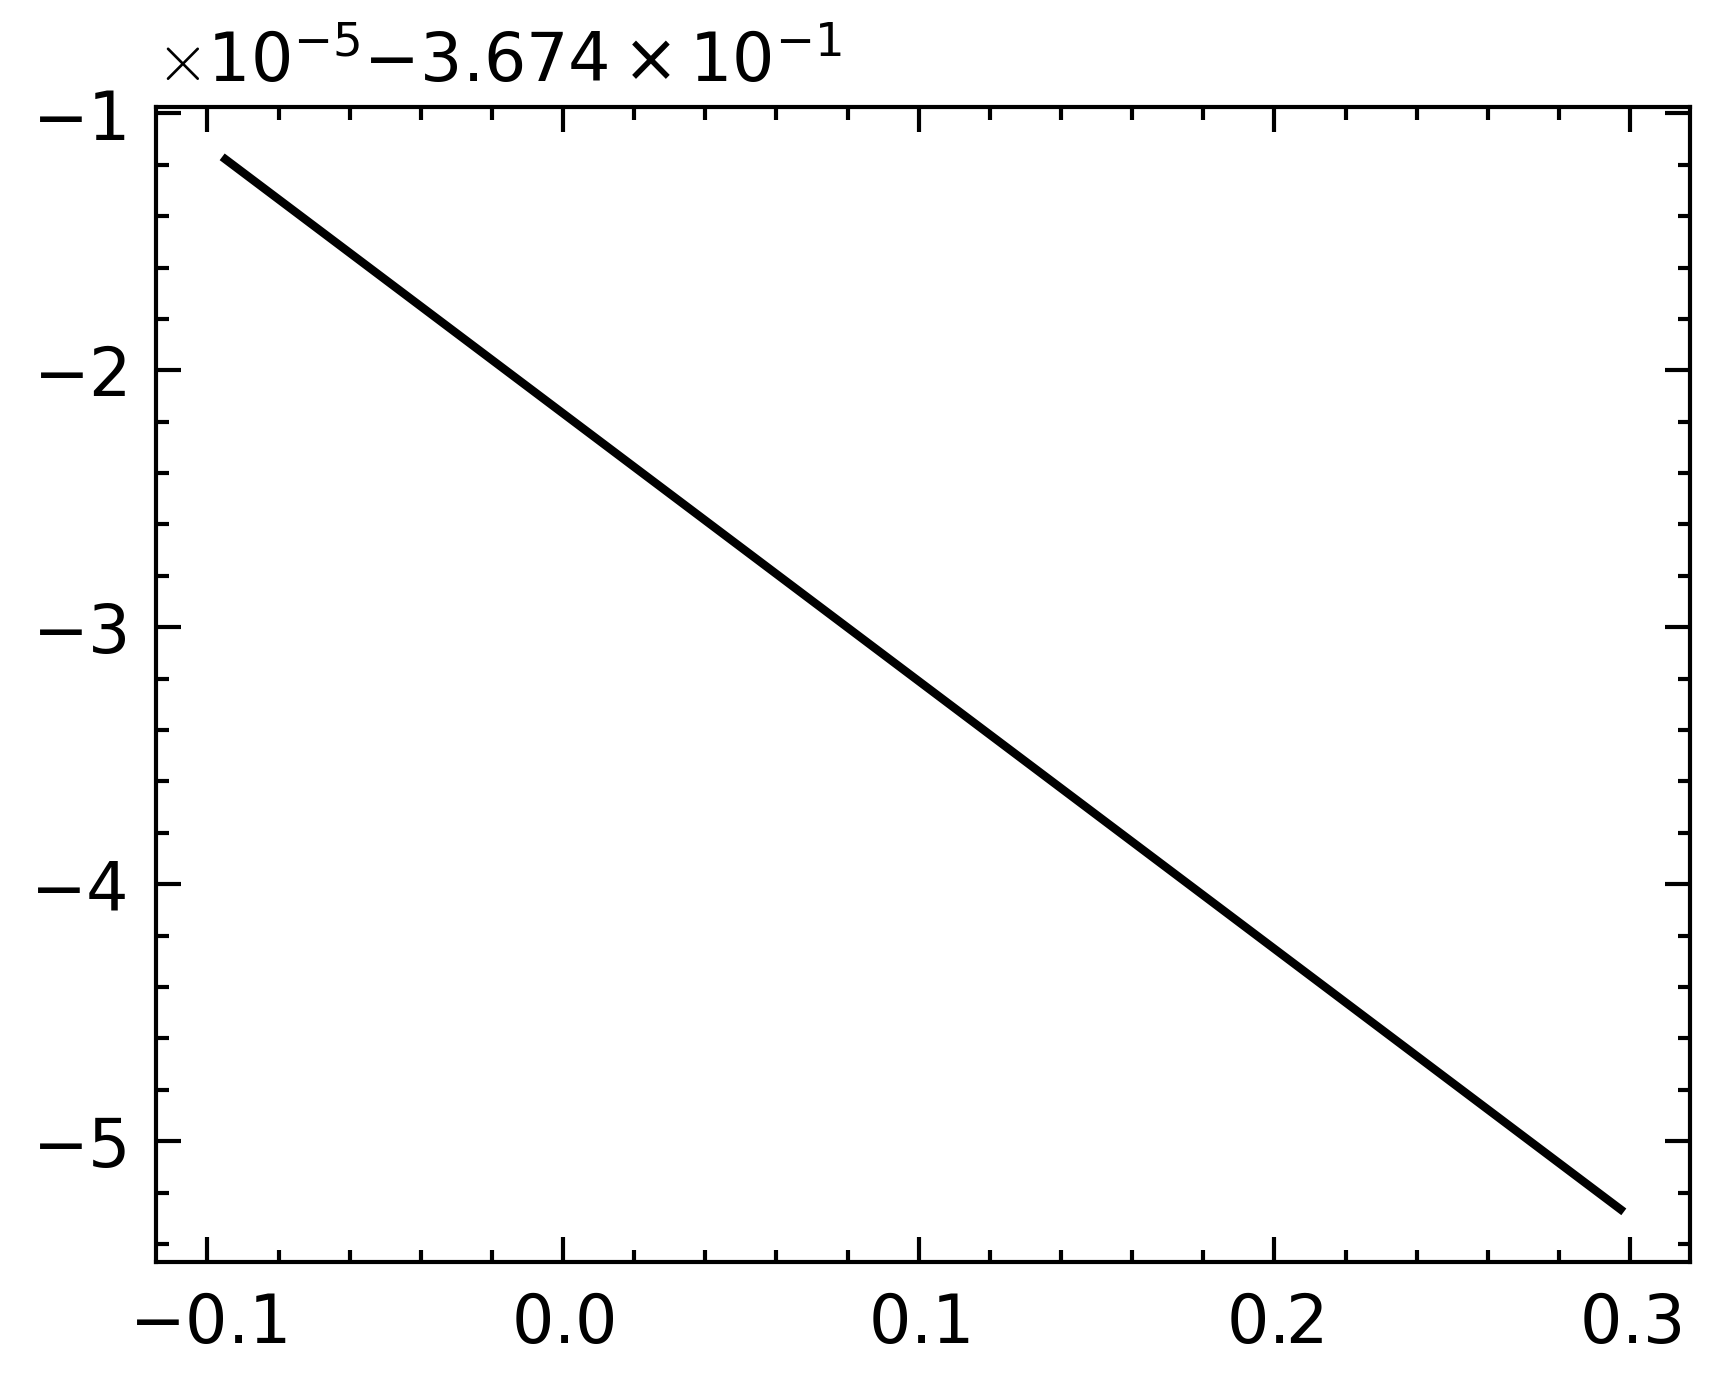

In [36]:
plt.plot(V,shockley(V,*prams))